# 🌳 HỆ THỐNG HỖ TRỢ QUYẾT ĐỊNH CẢNH BÁO SỚM SINH VIÊN CÓ NGUY CƠ RỚT MÔN
## DSS lai 2 tầng: AHP (trọng số nghiệp vụ) + Decision Tree (dự báo)

**Mô hình:**
- **AHP** trả lời: *"Tiêu chí nào quan trọng hơn theo chuyên gia?"*
- **Decision Tree** trả lời: *"Từ dữ liệu lịch sử, sinh viên nào có khả năng rớt?"*

**Dữ liệu đầu vào:**
- `Test_Score`: Điểm kiểm tra giữa kỳ (0-10)
- `Attendance (%)`: Tỷ lệ tham dự lớp (%)
- `Study_Hours`: Số giờ học trung bình mỗi ngày

**Kết quả:** Xác suất rớt (`p_fail`), điểm rủi ro AHP (`ahp_score`), điểm kết hợp (`final_score`), mức cảnh báo (Cao/Trung bình/Thấp)

## 1. Import thư viện

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_curve, f1_score)
import joblib
import matplotlib.pyplot as plt

from modules.ahp import calculate_weights, is_consistent, SAATY_SCALE, get_ri
from modules.risk_engine import (calculate_ahp_score, calculate_final_score,
                                 classify_risk_level, get_top_risk_factors,
                                 generate_warning_reason, suggest_intervention)

print("✅ Import thư viện và modules thành công!")

✅ Import thư viện và modules thành công!


## 2. Đọc dữ liệu

In [2]:
# Đọc file Excel 1K dữ liệu điểm
DATA_PATH = os.path.join("..", "data", "1k_Data điểm.xlsx")
MODEL_PATH = "decision_tree_model.pkl"

df = pd.read_excel(DATA_PATH)
print(f"📊 Đọc dữ liệu thành công: {df.shape[0]} dòng, {df.shape[1]} cột")
print(f"📋 Các cột: {df.columns.tolist()}\n")
df.head(10)

📊 Đọc dữ liệu thành công: 1000 dòng, 5 cột
📋 Các cột: ['Name', 'Class', 'Test_Score', 'Attendance (%)', 'Study_Hours']



,Name,Class,Test_Score,Attendance (%),Study_Hours
0,Hoàng Hữu Linh,11CNTT1,6.5,98.73,6.0
1,Hoàng Hữu Mai,11CNTT1,7.0,83.75,5.5
2,Hoàng Minh Hùng,11CNTT1,3.5,61.56,1.0
3,Hoàng Minh Khanh,11CNTT1,2.0,62.29,1.5
4,Hoàng Minh Phúc,11CNTT1,2.5,69.96,1.5
5,Hoàng Ngọc Tuấn,11CNTT1,2.5,70.75,1.0
6,Hoàng Thanh Linh,11CNTT1,6.0,78.96,3.5
7,Hoàng Thị Linh,11CNTT1,2.5,65.44,2.0
8,Hoàng Thị Trang,11CNTT1,7.5,98.49,6.5
9,Hoàng Văn Bình,11CNTT1,5.5,92.00,6.0


In [3]:
# Thống kê mô tả dữ liệu
df.describe()

,Test_Score,Attendance (%),Study_Hours
count,1000.000000,1000.000000,1000.000000
mean,5.278500,80.048930,3.775500
std,1.789243,11.350659,1.729839
min,0.000000,60.000000,0.500000
25%,4.000000,70.137500,2.500000
50%,5.500000,80.440000,3.750000
75%,6.500000,89.677500,5.000000
max,9.500000,99.970000,8.000000


## 3. Tiền xử lý dữ liệu (Preprocessing)

Các bước tiền xử lý:
1. **Data Cleaning** – Kiểm tra và loại bỏ dữ liệu trùng lặp
2. **Xử lý Missing** – Kiểm tra và xử lý giá trị null/NaN
3. **Chuẩn hóa** – Chuẩn hóa Min-Max cho Decision Tree (tùy chọn, DT không bắt buộc)
4. **Encoding** – Mã hóa biến phân loại (nếu có)
5. **Feature Selection** – Chọn các đặc trưng đầu vào

In [ ]:
# =============================================
# 3a. DATA CLEANING – Loại bỏ trùng lặp
# =============================================
print("=" * 50)
print("  3a. DATA CLEANING")
print("=" * 50)

# Kiểm tra dữ liệu trùng lặp
duplicates = df.duplicated().sum()
print(f"\n📋 Số dòng trùng lặp: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"   ✅ Đã loại bỏ {duplicates} dòng trùng → Còn {len(df)} dòng")
else:
    print("   ✅ Không có dòng trùng lặp")

# Kiểm tra kiểu dữ liệu
print(f"\n📋 Kiểu dữ liệu các cột:")
print(df.dtypes.to_string())

# Kiểm tra giá trị bất thường (outlier theo miền giá trị hợp lệ)
print(f"\n📋 Kiểm tra miền giá trị hợp lệ:")
invalid_score = ((df["Test_Score"] < 0) | (df["Test_Score"] > 10)).sum()
invalid_attend = ((df["Attendance (%)"] < 0) | (df["Attendance (%)"] > 100)).sum()
invalid_study = ((df["Study_Hours"] < 0) | (df["Study_Hours"] > 24)).sum()

print(f"   - Test_Score ngoài [0, 10]:      {invalid_score} dòng")
print(f"   - Attendance ngoài [0, 100]:      {invalid_attend} dòng")
print(f"   - Study_Hours ngoài [0, 24]:      {invalid_study} dòng")

# Loại bỏ dòng bất thường nếu có
n_invalid = invalid_score + invalid_attend + invalid_study
if n_invalid > 0:
    df = df[
        (df["Test_Score"] >= 0) & (df["Test_Score"] <= 10) &
        (df["Attendance (%)"] >= 0) & (df["Attendance (%)"] <= 100) &
        (df["Study_Hours"] >= 0) & (df["Study_Hours"] <= 24)
    ].reset_index(drop=True)
    print(f"   ✅ Đã loại bỏ {n_invalid} dòng bất thường → Còn {len(df)} dòng")
else:
    print("   ✅ Tất cả giá trị nằm trong miền hợp lệ")

In [ ]:
# =============================================
# 3b. XỬ LÝ MISSING VALUES
# =============================================
print("=" * 50)
print("  3b. XỬ LÝ MISSING VALUES")
print("=" * 50)

# Kiểm tra null/NaN
missing = df.isnull().sum()
total_missing = missing.sum()

print(f"\n📋 Số giá trị thiếu (NaN) theo từng cột:")
print(missing.to_string())
print(f"\n   Tổng giá trị thiếu: {total_missing}")

if total_missing > 0:
    # Xử lý: điền giá trị trung vị cho cột số
    numeric_cols = ["Test_Score", "Attendance (%)", "Study_Hours"]
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"   ✅ Cột '{col}': điền median = {median_val}")

    # Xử lý cột text: điền "Unknown"
    text_cols = ["Name", "Class"]
    for col in text_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna("Unknown", inplace=True)
            print(f"   ✅ Cột '{col}': điền 'Unknown'")

    print(f"\n   ✅ Đã xử lý xong missing values")
else:
    print("   ✅ Không có giá trị thiếu – dữ liệu đầy đủ")

In [ ]:
# =============================================
# 3c. CHUẨN HÓA DỮ LIỆU (Normalization)
# =============================================
print("=" * 50)
print("  3c. CHUẨN HÓA DỮ LIỆU")
print("=" * 50)

# Decision Tree KHÔNG yêu cầu chuẩn hóa (scale-invariant),
# nhưng thực hiện Min-Max để phục vụ AHP Risk Score sau này.

from sklearn.preprocessing import MinMaxScaler

features_to_normalize = ["Test_Score", "Attendance (%)", "Study_Hours"]

scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])

print(f"\n📋 Chuẩn hóa Min-Max [0, 1] cho các cột: {features_to_normalize}")
print(f"\n   Trước chuẩn hóa:")
print(df[features_to_normalize].describe().loc[["min", "max", "mean"]].round(2).to_string())
print(f"\n   Sau chuẩn hóa:")
print(df_normalized[features_to_normalize].describe().loc[["min", "max", "mean"]].round(2).to_string())

print(f"\n   ⚠️ Lưu ý: Decision Tree dùng dữ liệu GỐC (không chuẩn hóa).")
print(f"   Dữ liệu chuẩn hóa dùng cho tính AHP Risk Score.")
print(f"   ✅ Chuẩn hóa hoàn tất")

In [ ]:
# =============================================
# 3d. ENCODING – Mã hóa biến phân loại
# =============================================
print("=" * 50)
print("  3d. ENCODING")
print("=" * 50)

# Kiểm tra cột phân loại (categorical)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

print(f"\n📋 Cột phân loại (object): {categorical_cols}")
print(f"📋 Cột số (numeric):       {numeric_cols}")

if categorical_cols:
    print(f"\n   Các cột phân loại: {categorical_cols}")
    for col in categorical_cols:
        n_unique = df[col].nunique()
        print(f"   - '{col}': {n_unique} giá trị duy nhất")

    # Cột Name, Class là định danh – không dùng làm feature, không cần encode
    print(f"\n   ⚠️ Cột 'Name' và 'Class' là thông tin định danh sinh viên,")
    print(f"      không phải đặc trưng dự đoán → KHÔNG cần mã hóa.")
    print(f"   ✅ Không cần encoding – tất cả features đầu vào đều là số")
else:
    print(f"\n   ✅ Không có cột phân loại – không cần encoding")

# =============================================
# 3e. FEATURE SELECTION – Chọn đặc trưng
# =============================================
print(f"\n{'=' * 50}")
print("  3e. FEATURE SELECTION")
print("=" * 50)

all_columns = df.columns.tolist()
selected_features = ["Test_Score", "Attendance (%)", "Study_Hours"]
excluded_columns = [c for c in all_columns if c not in selected_features]

print(f"\n📋 Tất cả cột trong dataset: {all_columns}")
print(f"📋 Cột được chọn làm FEATURES: {selected_features}")
print(f"📋 Cột LOẠI BỎ (không phải đặc trưng): {excluded_columns}")

print(f"\n   Lý do chọn 3 features:")
print(f"   - Test_Score:      Phản ánh năng lực học tập trực tiếp")
print(f"   - Attendance (%):  Phản ánh mức độ chuyên cần")
print(f"   - Study_Hours:     Phản ánh nỗ lực tự học")
print(f"\n   Lý do loại bỏ:")
print(f"   - Name:  Thông tin định danh, không có giá trị dự đoán")
print(f"   - Class: Lớp học, không ảnh hưởng đến nguy cơ rớt")
print(f"\n   ✅ Feature Selection hoàn tất: {len(selected_features)} features")

## 4. Tạo nhãn nhị phân (Binary Label)

**Phân loại nhị phân:**
- 🔴 **Rớt (1):** `Test_Score < 4.0` HOẶC `Attendance < 50%`
- 🟢 **Không rớt (0):** Ngược lại

> **Lưu ý:** Mô hình dùng nhãn nhị phân để tập trung vào dự báo nguy cơ rớt môn.
> Mức cảnh báo 3 bậc (Cao/Trung bình/Thấp) sẽ được tính ở bước Risk Engine bằng `final_score`.

✅ Tạo nhãn nhị phân thành công!
   🟢 Không rớt (0): 783 sinh viên (78.3%)
   🔴 Rớt (1):       217 sinh viên (21.7%)


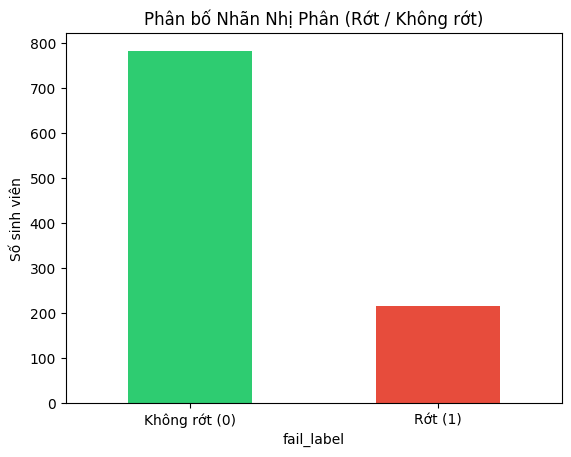

In [4]:
def create_binary_label(row):
    """Phân loại nhị phân: 1 = rớt, 0 = không rớt"""
    if row["Test_Score"] < 4.0:
        return 1  # Rớt – điểm quá thấp
    if row["Attendance (%)"] < 50.0:
        return 1  # Rớt – vắng quá nhiều
    return 0      # Không rớt

df["fail_label"] = df.apply(create_binary_label, axis=1)

n_fail = (df["fail_label"] == 1).sum()
n_pass = (df["fail_label"] == 0).sum()
total = len(df)

print(f"✅ Tạo nhãn nhị phân thành công!")
print(f"   🟢 Không rớt (0): {n_pass} sinh viên ({n_pass/total*100:.1f}%)")
print(f"   🔴 Rớt (1):       {n_fail} sinh viên ({n_fail/total*100:.1f}%)")

# Biểu đồ phân bố
colors = ["#2ecc71", "#e74c3c"]
df["fail_label"].value_counts().sort_index().plot(kind="bar", color=colors)
plt.xticks([0, 1], ["Không rớt (0)", "Rớt (1)"], rotation=0)
plt.title("Phân bố Nhãn Nhị Phân (Rớt / Không rớt)")
plt.ylabel("Số sinh viên")
plt.show()

## 5. Chia dữ liệu Train / Test (Nhị phân)

In [5]:
features = ["Test_Score", "Attendance (%)", "Study_Hours"]
X = df[features]
y = df["fail_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Chia dữ liệu (nhị phân):")
print(f"   - Train: {len(X_train)} mẫu (80%)")
print(f"   - Test:  {len(X_test)} mẫu (20%)")
print(f"   - Train  → Không rớt: {(y_train==0).sum()}, Rớt: {(y_train==1).sum()}")
print(f"   - Test   → Không rớt: {(y_test==0).sum()}, Rớt: {(y_test==1).sum()}")

📊 Chia dữ liệu (nhị phân):
   - Train: 800 mẫu (80%)
   - Test:  200 mẫu (20%)
   - Train  → Không rớt: 626, Rớt: 174
   - Test   → Không rớt: 157, Rớt: 43


## 6. Huấn luyện Decision Tree (nhị phân, class_weight='balanced')

In [6]:
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",   # Cân bằng khi dữ liệu mất cân bằng
    random_state=42,
    criterion="gini",
)

model.fit(X_train, y_train)

print(f"✅ Huấn luyện Decision Tree (nhị phân) thành công!")
print(f"   - Độ sâu cây:  {model.get_depth()}")
print(f"   - Số lá:        {model.get_n_leaves()}")
print(f"   - class_weight: balanced")

✅ Huấn luyện Decision Tree (nhị phân) thành công!
   - Độ sâu cây:  2
   - Số lá:        3
   - class_weight: balanced


## 7. Đánh giá mô hình (Confusion Matrix, Precision, Recall, F1)

🎯 Accuracy: 100.00%

📋 Classification Report:
               precision    recall  f1-score   support

Không rớt (0)       1.00      1.00      1.00       157
      Rớt (1)       1.00      1.00      1.00        43

     accuracy                           1.00       200
    macro avg       1.00      1.00      1.00       200
 weighted avg       1.00      1.00      1.00       200



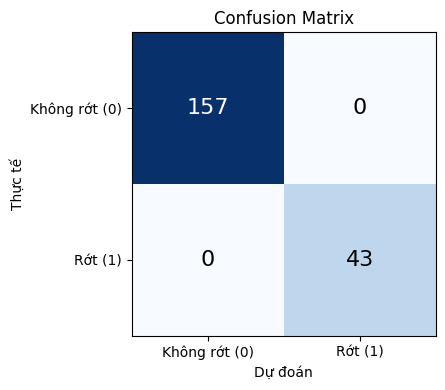

In [7]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

class_names = ["Không rớt (0)", "Rớt (1)"]

print(f"🎯 Accuracy: {accuracy*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix trực quan
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i][j]), ha='center', va='center',
                color='white' if cm[i][j] > cm.max()/2 else 'black', fontsize=16)
plt.tight_layout()
plt.show()

## 8. Cấu trúc cây quyết định & Threshold Tuning

In [8]:
# 7a. Cấu trúc cây dạng text
print("🌳 CẤU TRÚC CÂY QUYẾT ĐỊNH (nhị phân):")
print("-" * 50)
tree_rules = export_text(model, feature_names=features, class_names=["Không rớt", "Rớt"])
print(tree_rules)

🌳 CẤU TRÚC CÂY QUYẾT ĐỊNH (nhị phân):
--------------------------------------------------
|--- Test_Score <= 3.75
|   |--- class: Rớt
|--- Test_Score >  3.75
|   |--- Study_Hours <= 0.75
|   |   |--- class: Không rớt
|   |--- Study_Hours >  0.75
|   |   |--- class: Không rớt



C:\Users\Admin\AppData\Local\Temp\ipykernel_28960\3701705327.py:10: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_28960\3701705327.py:11: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


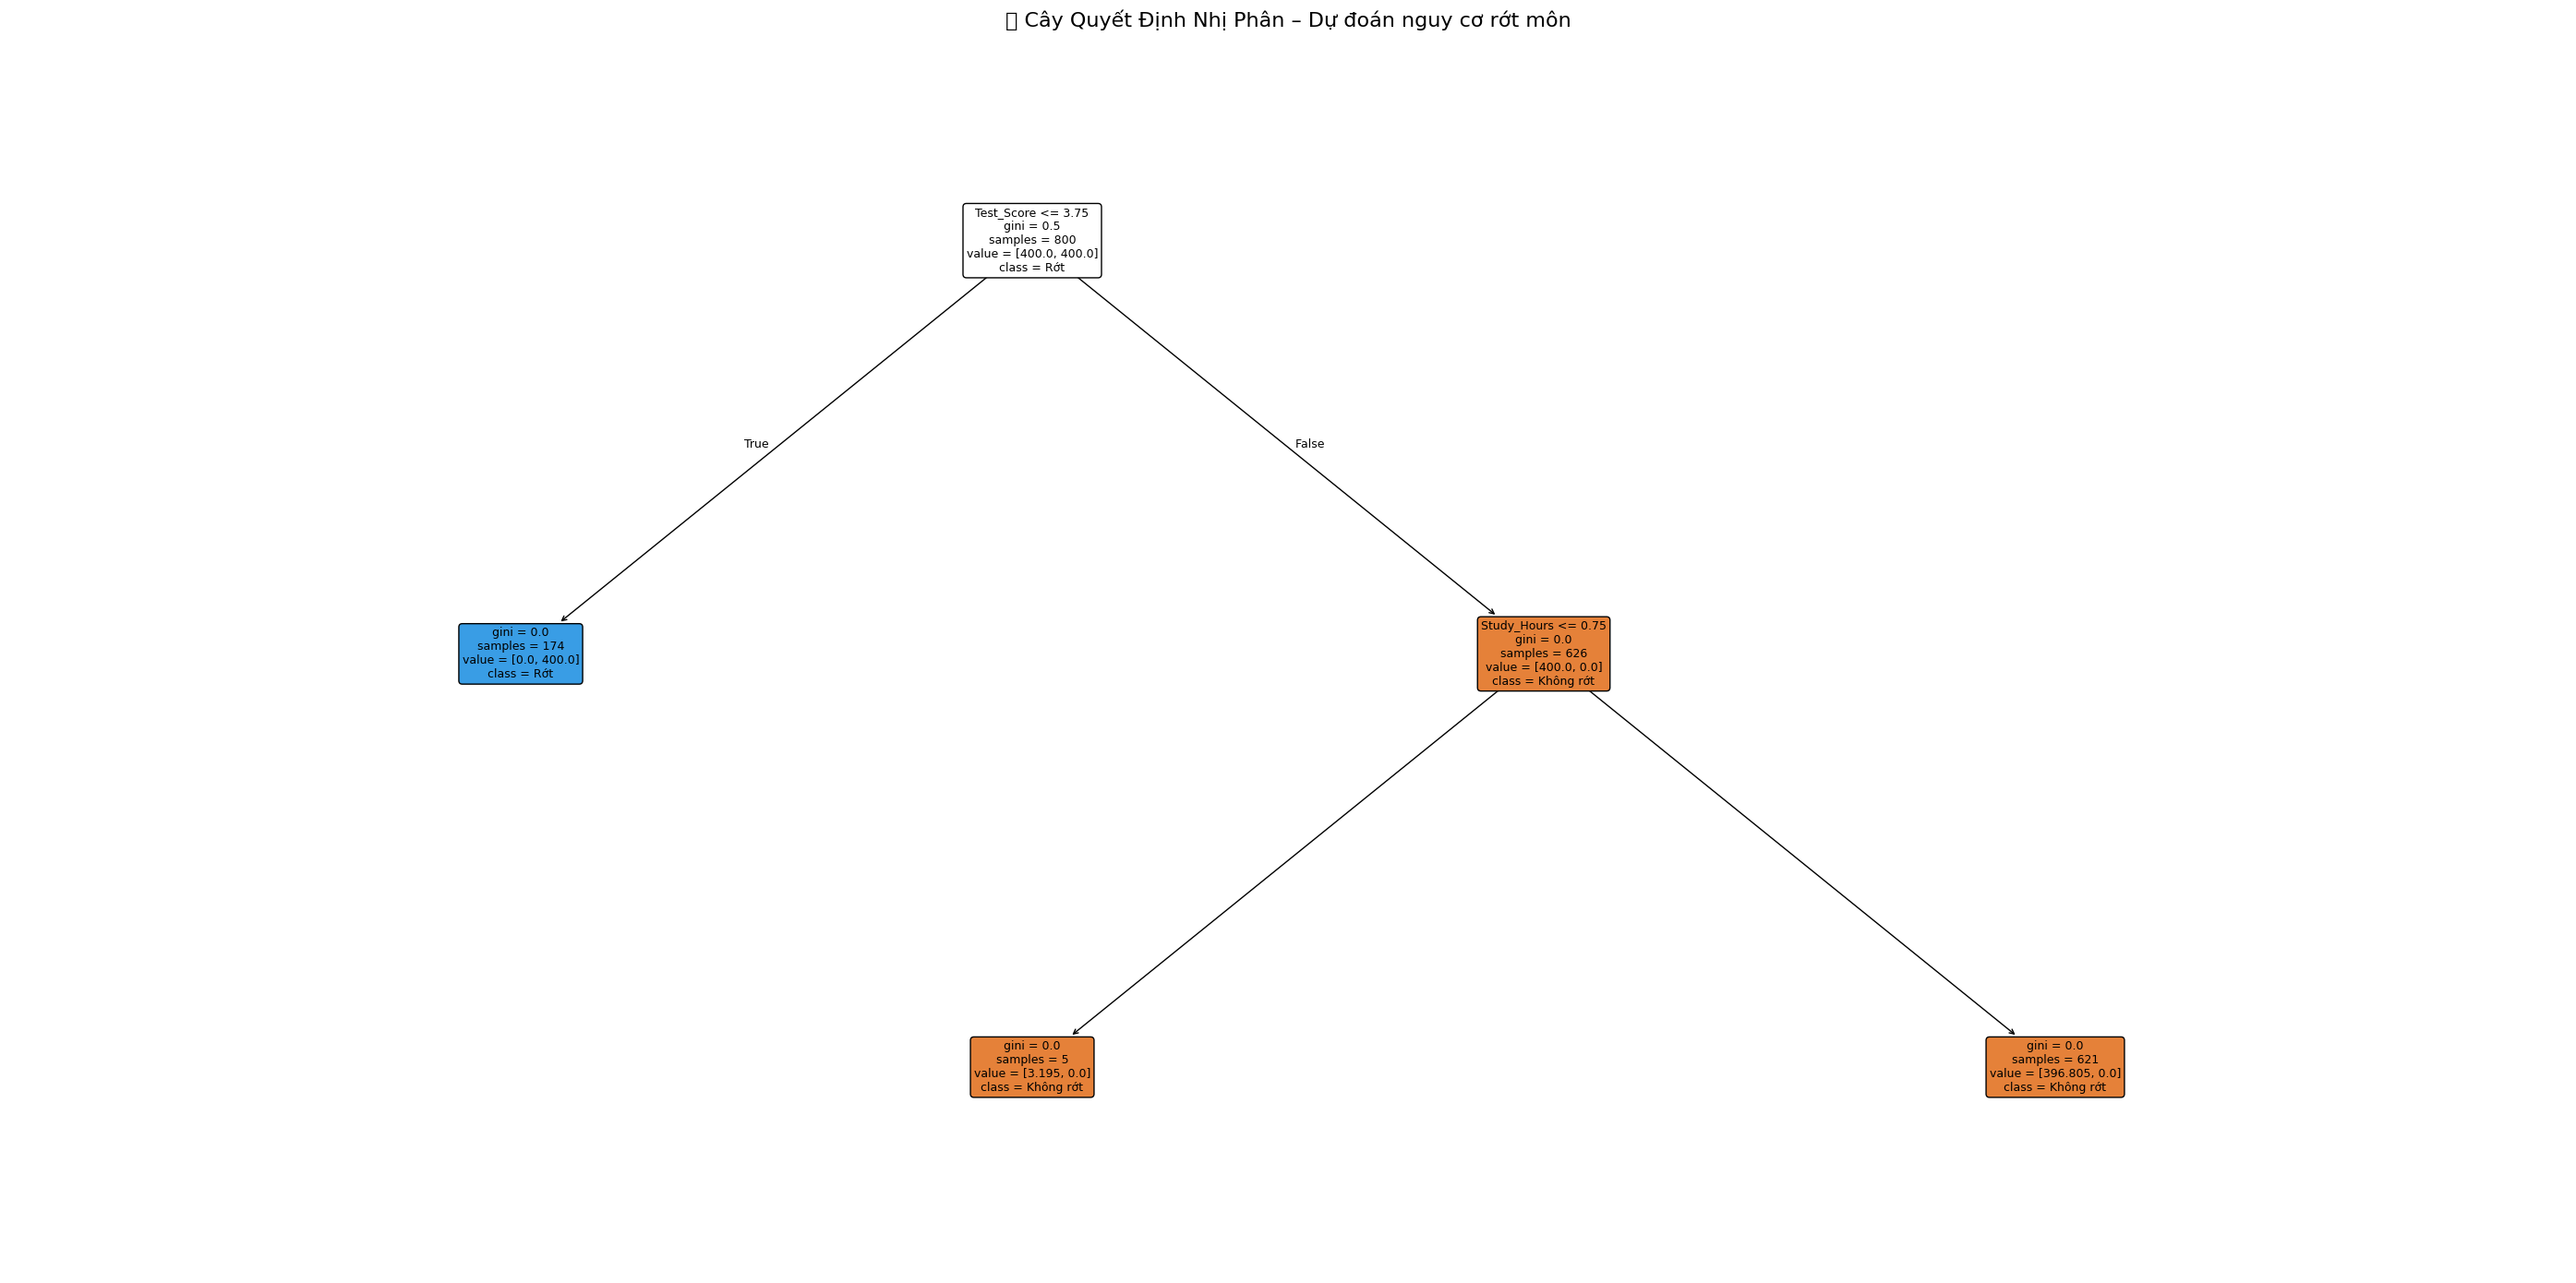

💾 Đã lưu: decision_tree.png


In [9]:
# 7b. Vẽ cây quyết định
fig, ax = plt.subplots(figsize=(28, 14))
plot_tree(
    model,
    feature_names=features,
    class_names=["Không rớt", "Rớt"],
    filled=True, rounded=True, fontsize=9, ax=ax,
)
plt.title("🌳 Cây Quyết Định Nhị Phân – Dự đoán nguy cơ rớt môn", fontsize=16)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Đã lưu: decision_tree.png")

## 9. Threshold Tuning (Điều chỉnh ngưỡng quyết định)

> Ngưỡng mặc định 0.5 thường **không tối ưu** cho bài toán cảnh báo sớm.
> Với hệ thống này, nên ưu tiên **Recall** (không bỏ sót sinh viên nguy cơ cao).

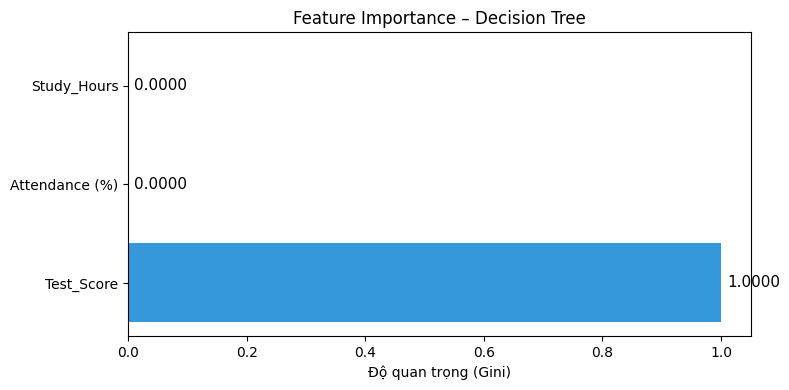

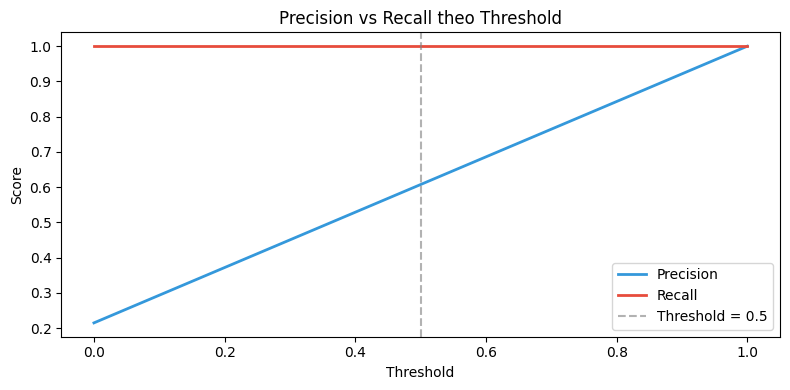


📊 SO SÁNH THRESHOLD:
   Threshold = 0.3 → F1 = 1.0000, Recall(rớt) = 1.0000
   Threshold = 0.4 → F1 = 1.0000, Recall(rớt) = 1.0000
   Threshold = 0.5 → F1 = 1.0000, Recall(rớt) = 1.0000
   Threshold = 0.6 → F1 = 1.0000, Recall(rớt) = 1.0000
   Threshold = 0.7 → F1 = 1.0000, Recall(rớt) = 1.0000


In [10]:
# 8a. Feature Importance
importances = model.feature_importances_

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(features, importances, color=["#3498db", "#e74c3c", "#2ecc71"])
ax.set_xlabel("Độ quan trọng (Gini)")
ax.set_title("Feature Importance – Decision Tree")
for bar, imp in zip(bars, importances):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{imp:.4f}", va="center", fontsize=11)
plt.tight_layout()
plt.show()

# 8b. Precision-Recall vs Threshold
y_proba = model.predict_proba(X_test)[:, 1]  # p(rớt)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precisions[:-1], label="Precision", color="#3498db", linewidth=2)
ax.plot(thresholds, recalls[:-1], label="Recall", color="#e74c3c", linewidth=2)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.6, label="Threshold = 0.5")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision vs Recall theo Threshold")
ax.legend()
plt.tight_layout()
plt.show()

# So sánh threshold 0.5 vs threshold tối ưu
print("\n📊 SO SÁNH THRESHOLD:")
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_t = (y_proba >= t).astype(int)
    f1_t = f1_score(y_test, y_t, zero_division=0)
    recall_t = (y_t[y_test == 1] == 1).mean() if (y_test == 1).sum() > 0 else 0
    print(f"   Threshold = {t:.1f} → F1 = {f1_t:.4f}, Recall(rớt) = {recall_t:.4f}")

## 10. AHP – Tính trọng số nghiệp vụ (Thang Saaty 1-9)

**Ma trận so sánh cặp 3 tiêu chí:**
- Điểm kiểm tra (`Test_Score`)
- Chuyên cần (`Attendance (%)`)
- Giờ tự học (`Study_Hours`)

**Công thức AHP:**
- Trọng số ưu tiên = eigenvector của ma trận so sánh cặp
- CI = (λ_max - n) / (n - 1)
- CR = CI / RI → CR ≤ 0.10 = nhất quán

📊 Ma trận so sánh cặp AHP:
            Điểm KT  Chuyên cần  Giờ học
Điểm KT      1.0000      3.0000      5.0
Chuyên cần   0.3333      1.0000      3.0
Giờ học      0.2000      0.3333      1.0

📐 Kết quả AHP:
   λ_max = 3.0385
   CI = 0.0193
   RI = 0.58
   CR = 0.0332
   ✅ Ma trận NHẤT QUÁN (CR ≤ 0.10)

⚖️ Trọng số AHP:
   Test_Score           0.6370  █████████████████████████
   Attendance (%)       0.2583  ██████████
   Study_Hours          0.1047  ████


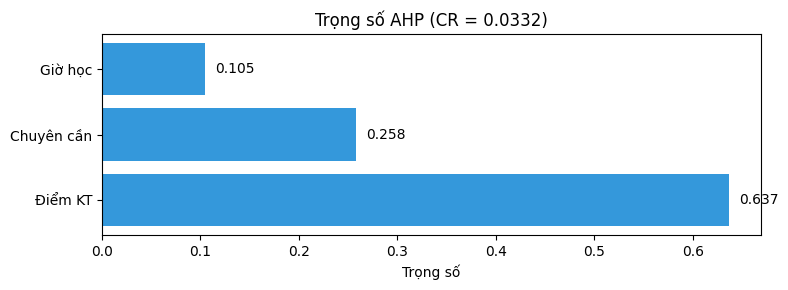

In [11]:
# 9a. Ma trận so sánh cặp (ví dụ: ý kiến chuyên gia)
# Test_Score quan trọng hơn Attendance vừa phải (3)
# Test_Score quan trọng hơn Study_Hours nhiều (5)
# Attendance quan trọng hơn Study_Hours vừa phải (3)
criteria = ["Test_Score", "Attendance (%)", "Study_Hours"]
ahp_matrix = np.array([
    [1,   3,   5],
    [1/3, 1,   3],
    [1/5, 1/3, 1],
])

print("📊 Ma trận so sánh cặp AHP:")
matrix_df = pd.DataFrame(ahp_matrix,
                          index=["Điểm KT", "Chuyên cần", "Giờ học"],
                          columns=["Điểm KT", "Chuyên cần", "Giờ học"])
print(matrix_df.round(4).to_string())

# 9b. Tính trọng số
weights, lambda_max, ci, cr = calculate_weights(ahp_matrix)
ri = get_ri(len(criteria))
consistent = is_consistent(cr)

print(f"\n📐 Kết quả AHP:")
print(f"   λ_max = {lambda_max:.4f}")
print(f"   CI = {ci:.4f}")
print(f"   RI = {ri:.2f}")
print(f"   CR = {cr:.4f}")
print(f"   {'✅ Ma trận NHẤT QUÁN (CR ≤ 0.10)' if consistent else '❌ Ma trận KHÔNG nhất quán (CR > 0.10)'}")
print(f"\n⚖️ Trọng số AHP:")
for c, w in zip(criteria, weights):
    bar = "█" * int(w * 40)
    print(f"   {c:<20} {w:.4f}  {bar}")

# Biểu đồ trọng số
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(["Điểm KT", "Chuyên cần", "Giờ học"], weights, color="#3498db")
ax.set_xlabel("Trọng số")
ax.set_title(f"Trọng số AHP (CR = {cr:.4f})")
for bar, w in zip(bars, weights):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{w:.3f}", va="center")
plt.tight_layout()
plt.show()

## 11. Risk Engine – Kết hợp AHP + Decision Tree

**Công thức kết hợp:**
- `p_fail` = xác suất rớt từ Decision Tree (`predict_proba`)
- `ahp_score` = tổng điểm rủi ro có trọng số AHP = Σ(w_i × risk_i)
- `final_score = 0.7 × p_fail + 0.3 × ahp_score`

**Ngưỡng cảnh báo:**
- 🔴 **Cao:** `final_score ≥ 0.75`
- 🟡 **Trung bình:** `0.55 ≤ final_score < 0.75`
- 🟢 **Thấp:** `final_score < 0.55`

✅ Kết hợp AHP + Decision Tree thành công!
   Công thức: final_score = 0.7 × p_fail + 0.30000000000000004 × ahp_score

   🔴 Rủi ro Cao:       217 sinh viên
   🟡 Rủi ro Trung bình: 0 sinh viên
   🟢 Rủi ro Thấp:      783 sinh viên


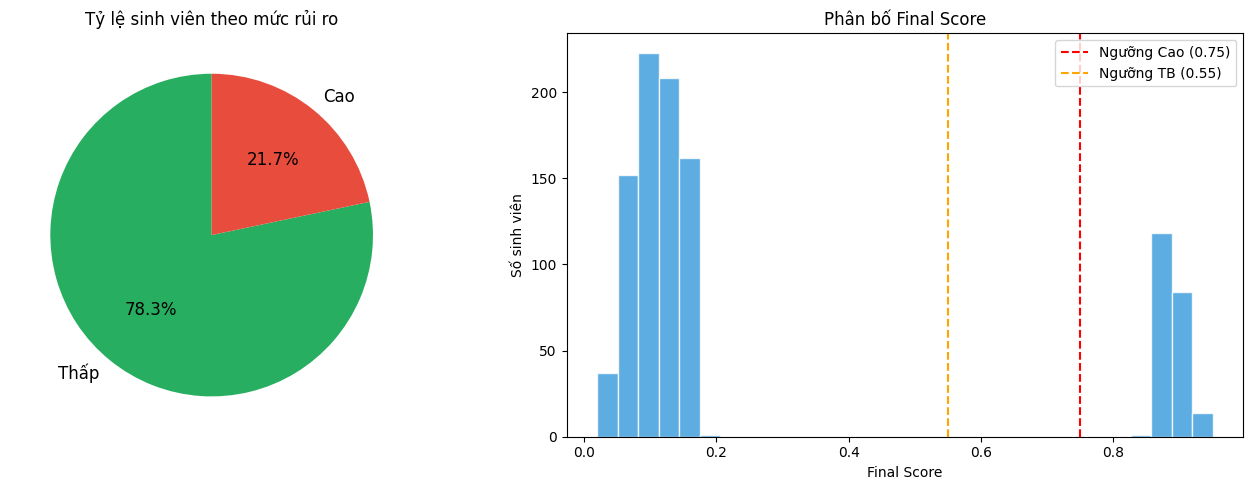

In [12]:
# 10a. Tính p_fail cho tất cả sinh viên
X_all = df[features]
p_fail_all = model.predict_proba(X_all)[:, 1]  # xác suất rớt

# 10b. Tính AHP score (điểm rủi ro có trọng số)
ahp_score_all, risk_details = calculate_ahp_score(df, criteria, weights)

# 10c. Tính final_score = 0.7 * p_fail + 0.3 * ahp_score
alpha = 0.7
final_score_all = calculate_final_score(p_fail_all, ahp_score_all, alpha)

# 10d. Phân loại mức rủi ro
risk_levels = classify_risk_level(final_score_all)

# Gắn kết quả vào DataFrame
df["p_fail"] = p_fail_all
df["ahp_score"] = ahp_score_all
df["final_score"] = final_score_all
df["Muc_rui_ro"] = risk_levels.values

print(f"✅ Kết hợp AHP + Decision Tree thành công!")
print(f"   Công thức: final_score = {alpha} × p_fail + {1-alpha} × ahp_score\n")
print(f"   🔴 Rủi ro Cao:       {(risk_levels == 'Cao').sum()} sinh viên")
print(f"   🟡 Rủi ro Trung bình: {(risk_levels == 'Trung bình').sum()} sinh viên")
print(f"   🟢 Rủi ro Thấp:      {(risk_levels == 'Thấp').sum()} sinh viên")

# Biểu đồ phân bố mức rủi ro
colors_map = {"Cao": "#e74c3c", "Trung bình": "#f39c12", "Thấp": "#27ae60"}
risk_counts = df["Muc_rui_ro"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
labels = risk_counts.index.tolist()
axes[0].pie(risk_counts.values, labels=labels,
            colors=[colors_map.get(l, "#999") for l in labels],
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
axes[0].set_title("Tỷ lệ sinh viên theo mức rủi ro")

# Histogram final_score
axes[1].hist(final_score_all, bins=30, color="#3498db", edgecolor="white", alpha=0.8)
axes[1].axvline(x=0.75, color="red", linestyle="--", label="Ngưỡng Cao (0.75)")
axes[1].axvline(x=0.55, color="orange", linestyle="--", label="Ngưỡng TB (0.55)")
axes[1].set_xlabel("Final Score")
axes[1].set_ylabel("Số sinh viên")
axes[1].set_title("Phân bố Final Score")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. So sánh 3 phương pháp: AHP-only vs DT-only vs Hybrid

So sánh hiệu quả phân loại giữa 3 cách:
1. **AHP-only**: chỉ dùng trọng số AHP
2. **DT-only**: chỉ dùng xác suất Decision Tree
3. **Hybrid AHP + DT**: kết hợp (phương pháp đề xuất)

In [13]:
# So sánh 3 phương pháp
# Lấy label thực tế
actual_fail = df["fail_label"].values

# 1) AHP-only: dùng ahp_score để phân loại
ahp_only_levels = classify_risk_level(ahp_score_all)
# 2) DT-only: dùng p_fail
dt_only_levels = classify_risk_level(p_fail_all)
# 3) Hybrid
hybrid_levels = classify_risk_level(final_score_all)

methods = {
    "AHP-only (ahp_score)": ahp_score_all,
    "DT-only (p_fail)": p_fail_all,
    "Hybrid (0.7·DT + 0.3·AHP)": final_score_all,
}

print("📊 SO SÁNH 3 PHƯƠNG PHÁP:")
print(f"{'Phương pháp':<30} {'Cao':>6} {'TB':>6} {'Thấp':>6}  {'Match rớt thật':>15}")
print("-" * 70)
for name, scores in methods.items():
    levels = classify_risk_level(scores)
    n_cao = (levels == "Cao").sum()
    n_tb = (levels == "Trung bình").sum()
    n_thap = (levels == "Thấp").sum()
    # "Cao" == rớt thật?
    flagged_as_high = levels == "Cao"
    match_rate = (actual_fail[flagged_as_high] == 1).mean() * 100 if flagged_as_high.sum() > 0 else 0
    print(f"   {name:<28} {n_cao:>5}  {n_tb:>5}  {n_thap:>5}  {match_rate:>12.1f}%")

# So sánh threshold mặc định vs 0.4
print(f"\n📊 SO SÁNH THRESHOLD (DT-only trên test set):")
for t in [0.5, 0.4, 0.3]:
    y_t = (model.predict_proba(X_test)[:, 1] >= t).astype(int)
    recall = (y_t[y_test == 1] == 1).mean() if (y_test == 1).sum() > 0 else 0
    precision = (y_test[y_t == 1] == 1).mean() if y_t.sum() > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"   Threshold={t:.1f} → Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

📊 SO SÁNH 3 PHƯƠNG PHÁP:
Phương pháp                       Cao     TB   Thấp   Match rớt thật
----------------------------------------------------------------------
   AHP-only (ahp_score)           122    620    258         100.0%
   DT-only (p_fail)               217      0    783         100.0%
   Hybrid (0.7·DT + 0.3·AHP)      217      0    783         100.0%

📊 SO SÁNH THRESHOLD (DT-only trên test set):
   Threshold=0.5 → Precision=1.000, Recall=1.000, F1=1.000
   Threshold=0.4 → Precision=1.000, Recall=1.000, F1=1.000
   Threshold=0.3 → Precision=1.000, Recall=1.000, F1=1.000


## 13. Lưu mô hình & Xuất dữ liệu kết hợp

In [14]:
# 12a. Lưu mô hình
MODEL_PATH = "decision_tree_model.pkl"
joblib.dump(model, MODEL_PATH)
print(f"💾 Đã lưu mô hình: {MODEL_PATH}")

# Cũng lưu vào thư mục models/ của app
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(model, os.path.join(MODELS_DIR, "decision_tree_model.pkl"))
print(f"💾 Đã lưu mô hình cho app: ../models/decision_tree_model.pkl")

# 12b. Xuất dữ liệu đã gán nhãn + điểm rủi ro
output_path = os.path.join("..", "data", "1k_Data_diem_labeled.xlsx")
df_out = df.copy()
df_out["Ket_Qua"] = df_out["fail_label"].map({0: "Không rớt", 1: "Rớt"})
df_out.to_excel(output_path, index=False)
print(f"💾 Đã xuất dữ liệu: {output_path}")
print(f"   Các cột: {df_out.columns.tolist()}")

# Top 10 sinh viên rủi ro cao nhất
print(f"\n🔴 TOP 10 SINH VIÊN RỦI RO CAO NHẤT:")
top10 = df_out.nlargest(10, "final_score")[
    ["Name", "Class", "Test_Score", "Attendance (%)", "Study_Hours",
     "p_fail", "ahp_score", "final_score", "Muc_rui_ro"]
]
print(top10.to_string(index=False))

print("\n✅ HOÀN TẤT TRAINING + AHP + RISK ENGINE!")

💾 Đã lưu mô hình: decision_tree_model.pkl
💾 Đã lưu mô hình cho app: ../models/decision_tree_model.pkl
💾 Đã xuất dữ liệu: ..\data\1k_Data_diem_labeled.xlsx
   Các cột: ['Name', 'Class', 'Test_Score', 'Attendance (%)', 'Study_Hours', 'fail_label', 'p_fail', 'ahp_score', 'final_score', 'Muc_rui_ro', 'Ket_Qua']

🔴 TOP 10 SINH VIÊN RỦI RO CAO NHẤT:
           Name    Class  Test_Score  Attendance (%)  Study_Hours  p_fail  ahp_score  final_score Muc_rui_ro
 Huỳnh Văn Quân  11CNTT8         0.0           62.98          0.5     1.0   0.832968     0.949891        Cao
  Phạm Thanh An  11CNTT8         0.5           60.18          1.0     1.0   0.803987     0.941196        Cao
  Đặng Văn Dũng  11CNTT4         0.5           63.91          0.5     1.0   0.798717     0.939615        Cao
 Huỳnh Quang Vy  11CNTT4         1.0           60.18          0.5     1.0   0.776502     0.932951        Cao
 Đặng Minh Hùng  11CNTT9         1.0           60.35          0.5     1.0   0.776063     0.932819        Cao
